<div style="background: linear-gradient(135deg, #0a0e27 0%, #1a2456 100%);
     padding: 36px 40px; border-radius: 12px; border-left: 6px solid #c9a84c;
     font-family: 'Georgia', serif;">
  <p style="color:#c9a84c; font-size:13px; letter-spacing:3px; margin:0 0 6px 0;
     text-transform:uppercase;">NPSC2002 · Space Exploration: Science, Technology and Industry</p>
  <h1 style="color:#ffffff; font-size:30px; margin:0 0 8px 0; font-weight:700;">
    Workshop 6: Payload Design and Instrument Science</h1>
  <p style="color:#8ab4d4; font-size:16px; margin:0 0 18px 0; font-style:italic;">
    From a question to a detector - how Kepler was designed to find Earths</p>
  <hr style="border:none; border-top:1px solid #2a3a6a; margin:18px 0;">
  <p style="color:#b0c4de; font-size:13px; margin:0;">
    📊 Format: 30% code · 70% design & analysis &nbsp;|&nbsp;
    🏆 This workshop contributes to your Workshop Portfolio (Assessment 1)
  </p>
</div>

## Learning Objectives

By the end of this workshop you will be able to:

1. Explain the role of a **Science Traceability Matrix (STM)** in connecting scientific goals to engineering choices
2. Use simple geometry to **derive a photometric precision requirement** from first principles
3. Download and interpret **real Kepler mission data** using the `lightkurve` Python package
4. **Complete the engineering columns** of an STM for a space telescope payload
5. Identify key **cost and risk trade-offs** in payload design using Kepler as a case study

---

## Overview

> *"How do you design an instrument to answer a question you've never been able to answer before?"*

Every space mission begins with a science question. But getting from that question to a working instrument in orbit requires a systematic bridge - one that translates scientific goals into engineering specifications, and keeps the team honest when costs rise and decisions get hard.

Today you will follow exactly that path, using one of the most successful space science missions ever flown: **NASA's Kepler Space Telescope** (2009-2018), which discovered more than 2,600 confirmed exoplanets.

The workshop has five parts:

| Part | Activity |
|------|----------|
| 1 | What is a payload? The Science Traceability Matrix |
| 2 | Transit geometry: deriving the precision requirement |
| 3 | Complete the STM: from science to engineering |
| 4 | Real Kepler data: does the instrument deliver? |
| 5 | Reflection and limits |


---
<div style="background:#0d1b3e; padding:14px 20px; border-radius:8px; border-left:4px solid #c9a84c;">
  <span style="color:#c9a84c; font-weight:700; font-size:16px;">PART 1</span>
  <span style="color:#ffffff; font-size:16px;"> - What were scientists actually trying to find out?</span>
  <span style="color:#8ab4d4; font-size:13px;"></span>
</div>

### The question that built a telescope

Before Kepler launched in 2009, astronomers had been wrestling with one of the oldest questions in science:

> **Are there other Earth-like planets? And if so, how common are they?**

This was not an idle philosophical question by 2009. The first confirmed exoplanet around a Sun-like star - 51 Pegasi b - had been discovered in 1995, and within a decade hundreds more had been found using the *radial velocity* method (watching stars wobble due to gravitational tug from orbiting planets). But all of these were overwhelmingly **gas giants** - Jupiter-sized or larger - because that's what radial velocity is sensitive to. The smaller, rockier planets that might support life were invisible to existing technology.

The scientific community, through NASA's Decadal Survey process (where astronomers collectively set priorities), had identified a clear set of questions for the next generation of missions:

| Priority question | Why it mattered |
|---|---|
| How common are planets in or near the habitable zone? | No one had any idea - estimates ranged from "nearly every star" to "extremely rare" |
| Do Earth-sized planets exist around Sun-like stars? | Theory said yes; no observation had confirmed it |
| What is the distribution of planet sizes and orbital periods? | The population statistics required to test planet formation models |
| How many stars host *multiple* planets? | Tells us whether our Solar System's architecture is typical |

These questions became the **science requirements** for what would become Kepler. They weren't written by engineers asking what they could build - they were written by scientists asking what they *needed to know*. The engineering challenge was then to figure out whether it was even possible to build an instrument sensitive enough to answer them.


### The transit method: how Kepler would answer these questions

If Earth-sized planets exist, how would you detect them from 100-3,000 light-years away? You can't image them directly (they're far too small and dim next to their host star). You can't measure their gravitational tug reliably (too small a signal). But you *can* wait for them to cross in front of their star - and watch the star get very slightly dimmer.

This is the **transit method**. When a planet passes between its star and the telescope, it blocks a tiny fraction of the starlight. The bigger the planet relative to the star, the deeper the dip. Crucially, the dip repeats at the planet's orbital period - which is how you confirm it's a planet and not noise.

The diagram below shows how the geometry of the transit produces the characteristic U-shaped dip in the light curve:

<div style="text-align:center; margin:16px 0;">
  <img src="https://assets.science.nasa.gov/dynamicimage/assets/science/astro/exo-explore/2023/09/656348main_ToV_transit_diag.jpg" alt="NASA transit photometry diagram showing a planet crossing a star and the resulting dip in the light curve" style="max-width:700px; width:100%; border-radius:8px; border:1px solid #2a3a6a;">
  <p style="color:#8ab4d4; font-size:12px; margin-top:6px;">
    The transit method - as a planet crosses the stellar disc, flux drops by δ = (R<sub>p</sub>/R<sub>s</sub>)².
    Credit: NASA Exoplanet Exploration / public domain
  </p>
</div>

**What the transit tells you directly:**
- **Transit depth** (Δ*F*/*F*) → planet-to-star **radius ratio**
- **Transit duration** → helps constrain the planet's **orbital radius** (combined with the star's radius)
- **Transit period** → the planet's **orbital period** (and from that, via Kepler's Third Law, the **semi-major axis**)

**What the transit does NOT tell you:**
- Planet **mass** (requires radial velocity follow-up)
- Atmospheric **composition** (requires transmission spectroscopy - what JWST now does)
- Whether the planet is actually **rocky** or a water/gas world

This limitation matters enormously for the STM, as you'll see in Part 4.


### Payload vs spacecraft bus

Every spacecraft has two fundamental parts:

- The **spacecraft bus** is the infrastructure: power system, attitude control, communications, thermal management, propulsion. It keeps the spacecraft alive and pointed. It does not do science.
- The **payload** is the reason the spacecraft exists: the cameras, spectrometers, radars, or detectors that make the measurements.

For Kepler, the payload was a single large photometer - essentially a very precisely engineered digital camera - attached to a 0.95-metre telescope. The bus was responsible for keeping that photometer pointed at the same 105 square-degree patch of sky in Cygnus-Lyra with exquisite stability for years at a time. Every bus design choice - orbit, attitude control system, pointing stability, thermal control - was driven by what the photometer needed.

This is the fundamental relationship: **the payload requirements drive the bus design**, not the reverse. When you read an STM, you are reading the formal document that encodes this relationship.


### The Science Traceability Matrix

The STM is the tool that makes the chain from scientific question to hardware specification explicit and auditable. It has two halves:

**Left side (Science) - what we want to know:**
- **Science Goal** → the broad, long-term objective set by the science community or Decadal Survey
- **Science Objective** → specific, testable questions the mission will answer
- **Physical Parameter** → the quantity that, if measured, answers the objective
- **Observable** → what the instrument actually detects (not always the same thing)

**Right side (Engineering) - how we will measure it:**
- **Measurement Requirement** → precision, cadence, and coverage needed
- **Instrument Requirement** → what the detector must be capable of
- **Mission Requirement** → orbit, duration, pointing stability needed
- **Data Product** → what gets delivered to scientists

The STM is read **left to right**: science drives engineering. Its other crucial function is the reverse - when a budget cut forces a design compromise, the STM makes explicit exactly *which science objective* that compromise sacrifices, and whether the mission is still worth flying at all.

In Parts 2-3, you will derive the key number that belongs in Kepler's measurement requirement column. In Part 3, you will fill in the STM. In Part 4, you will work with real Kepler data to verify your answers.

---

### ✏️ Reflection 1.1

Look at the four priority science questions in the table at the top of this Part.

**Before Kepler, the best estimate for the fraction of Sun-like stars with Earth-sized planets in their habitable zone ranged from ~1% to nearly 100% - an uncertainty of two orders of magnitude.** Why was this uncertainty so large, and why couldn't existing ground-based or space-based telescopes narrow it down? Think about what makes the transit method specifically suited to answering this question at scale. *(3-5 sentences)*


**Your answer to Reflection 1.1:**

Before Kepler, the uncertainty was very large because existing detection methods mainly found large gas giants. Also, Earth sized planets produced signals which were too small to measure easily. The ground based telescopes were limited by atmospheric interference and earlier space telescopes were not stable enough to monitor enough stars for the tiny transit signals. The transit method allowed Kepler to observe over 150,000 stars at once and detect the small drops in brightness caused by Earth-sized planets crossing in front of their stars.



---
<div style="background:#0d1b3e; padding:14px 20px; border-radius:8px; border-left:4px solid #c9a84c;">
  <span style="color:#c9a84c; font-weight:700; font-size:16px;">PART 2</span>
  <span style="color:#ffffff; font-size:16px;"> - Transit geometry: deriving the precision requirement</span>
  <span style="color:#8ab4d4; font-size:13px;"></span>
</div>

### From geometry to a number

You have already seen the transit diagram in Part 1. Now we turn the geometry into a number.

When a planet of radius $R_p$ transits a star of radius $R_s$, the fraction of starlight blocked is the ratio of their *areas*:

$$\delta = \left(\frac{R_p}{R_s}\right)^2$$

This fractional dip $\delta$ is the **transit depth** - the fundamental observable for transit photometry.

The key question for instrument design: **how precisely must we measure stellar flux to detect a transit of a given depth?**

That answer becomes the **measurement requirement** in the STM. Let's derive it for three planet types now.


In [1]:
# ── PART 2: Transit Depth Calculation ──────────────────────────────────────
# Run this cell. The code is pre-written - your job is to read the output
# and answer the reflection questions below.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Physical constants ──────────────────────────────────────────────────────
R_sun   = 695_700   # km - radius of the Sun (also our reference star)
R_earth =   6_371   # km - radius of Earth
R_jup   =  71_492   # km - radius of Jupiter

# ── Three planet scenarios ──────────────────────────────────────────────────
scenarios = {
    "Hot Jupiter\n(1 Rⱼ)":       R_jup,
    "Super-Earth\n(2 R⊕)":      2 * R_earth,
    "Earth analogue\n(1 R⊕)":       R_earth,
}

print("=" * 60)
print("  Transit Depth: δ = (Rp / Rs)²")
print("  Star: Sun-like  (Rs = {:,} km)".format(R_sun))
print("=" * 60)

depths_ppm = {}
for label, rp in scenarios.items():
    depth_frac = (rp / R_sun) ** 2
    depth_pct  = depth_frac * 100
    depth_ppm  = depth_frac * 1_000_000   # parts per million
    depths_ppm[label] = depth_ppm
    print(f"\n{label.replace(chr(10),' '):30s}")
    print(f"  Planet radius : {rp:>8,} km")
    print(f"  Transit depth : {depth_frac:.6f}  ({depth_pct:.4f}%)  ({depth_ppm:.0f} ppm)")

print("\n" + "=" * 60)
print("  1 ppm = 0.0001% = a change of 1 part in 1,000,000")
print("=" * 60)


  Transit Depth: δ = (Rp / Rs)²
  Star: Sun-like  (Rs = 695,700 km)

Hot Jupiter (1 Rⱼ)            
  Planet radius :   71,492 km
  Transit depth : 0.010560  (1.0560%)  (10560 ppm)

Super-Earth (2 R⊕)            
  Planet radius :   12,742 km
  Transit depth : 0.000335  (0.0335%)  (335 ppm)

Earth analogue (1 R⊕)         
  Planet radius :    6,371 km
  Transit depth : 0.000084  (0.0084%)  (84 ppm)

  1 ppm = 0.0001% = a change of 1 part in 1,000,000


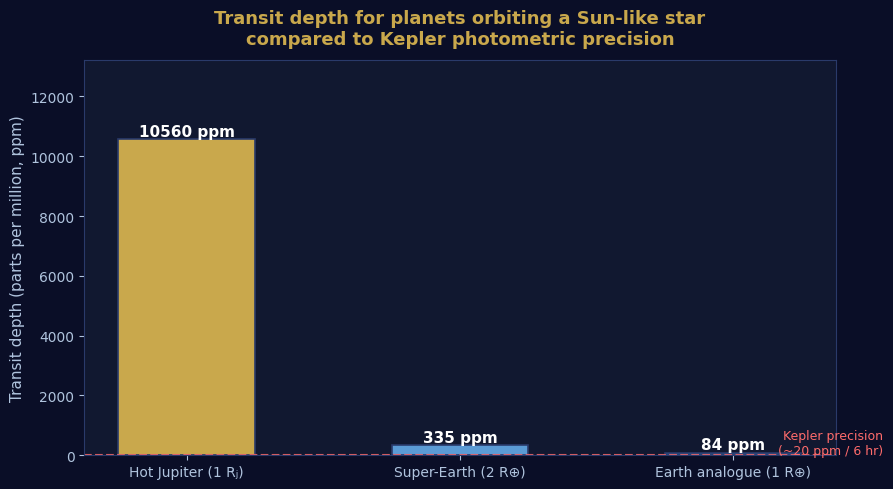


NOTE: A bar sitting ABOVE the red line is detectable by Kepler.
A bar BELOW the red line would require a more sensitive instrument.


In [2]:
# ── Bar chart: visualising the challenge ────────────────────────────────────

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0a0e27')
ax.set_facecolor('#111830')

labels = list(depths_ppm.keys())
values = list(depths_ppm.values())
colours = ['#c9a84c', '#5b9bd5', '#2e75b6']
clean_labels = [l.replace('\n', ' ') for l in labels]

bars = ax.bar(clean_labels, values, color=colours, width=0.5,
              edgecolor='#2a3a6a', linewidth=1.2)

# Annotate each bar
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 12,
            f'{val:.0f} ppm', ha='center', va='bottom',
            color='white', fontsize=11, fontweight='bold')

# Reference line: Kepler quoted photometric precision
kepler_precision = 20   # ppm per 6-hour integration (approx.)
ax.axhline(kepler_precision, color='#ff6b6b', linewidth=1.5,
           linestyle='--', alpha=0.85)
ax.text(2.55, kepler_precision + 15, "Kepler precision\n(~20 ppm / 6 hr)",
        color='#ff6b6b', fontsize=9, ha='right')

ax.set_ylabel('Transit depth (parts per million, ppm)', color='#b0c4de', fontsize=11)
ax.set_title('Transit depth for planets orbiting a Sun-like star\n'
             'compared to Kepler photometric precision',
             color='#c9a84c', fontsize=13, fontweight='bold', pad=12)
ax.tick_params(colors='#b0c4de', labelsize=10)
for spine in ax.spines.values():
    spine.set_edgecolor('#2a3a6a')
ax.set_ylim(0, max(values) * 1.25)
ax.yaxis.label.set_color('#b0c4de')

plt.tight_layout()
plt.show()

print("\nNOTE: A bar sitting ABOVE the red line is detectable by Kepler.")
print("A bar BELOW the red line would require a more sensitive instrument.")


### Reading the chart

The red dashed line represents Kepler photometric precision: approximately **20 ppm per 6-hour integration** for a bright (12th magnitude) star. Any transit deeper than this line is, in principle, detectable.

Notice that a hot Jupiter (~11,000 ppm) is so deep that ground-based telescopes can find it. An Earth analogue (~84 ppm) sits only ~4x above the noise floor - marginal even for Kepler. This is why finding true Earth analogues was Kepler's most demanding science objective.

---

### Reflection 2.1

**a)** Kepler-7b has a radius of 1.614 R_Jup and orbits a star of radius 1.843 R_sun. Using the formula d = (Rp/Rs)^2, calculate its expected transit depth in ppm. Use the scratch cell below. Does your answer match the bar chart?

**b)** The number you calculated in (a) is the value that would appear in the **Measurement Requirement** column of an STM for a mission targeting hot Jupiters. In your own words, explain why this number drives the instrument design - what happens if the detector is less precise than this value?


In [6]:
# Scratch space for Reflection 2.1a
# Calculate the expected transit depth for Kepler-7b
# Hint: R_sun and R_jup are already defined above

# Your code here:

Rp = 1.614*R_jup
Rs = 1.843*R_sun

d = (Rp/Rs)**2

ppm = d*1e6
print(ppm)


8098.923131399195


**Your written answer to Reflection 2.1b:**

The calculated value drives the instrument design because the detector must be sensitive enough to measure brightness changes at least at this small. If the detector precision is less than the transit depth, the planet's signal could not be detected reliably.

---
<div style="background:#0d1b3e; padding:14px 20px; border-radius:8px; border-left:4px solid #c9a84c;">
  <span style="color:#c9a84c; font-weight:700; font-size:16px;">PART 3</span>
  <span style="color:#ffffff; font-size:16px;"> - Complete the STM: from science to engineering</span>
  <span style="color:#8ab4d4; font-size:13px;"></span>
</div>

### Your task

Below is the Science Traceability Matrix for a transit photometry mission, based closely on Kepler's actual mission design. The left four columns are pre-filled (the science side). Your task is to complete the right four columns (the engineering side).

The precision number you derived in Part 2 belongs in the Measurement Requirement column for Objective A. Use it. For the other columns, use the guidance notes beneath the table, and feel free to do brief searches for instrument specifications.

Read the pre-filled columns carefully before starting.


### Pre-filled STM (science side) - read before completing your version below

| | Science Goal | Science Objective | Physical Parameter | Observable |
|---|---|---|---|---|
| **Obj A** | Determine the frequency of Earth-sized and larger planets in or near the habitable zone of a wide variety of stellar types | Detect and characterise terrestrial and larger planets in the habitable zone of solar-like stars | Stellar flux decrease due to planetary transit (fractional) | Stellar brightness vs time: a repeating dip of depth d = (Rp/Rs)^2 |
| **Obj B** | (same) | Determine the distribution of planet sizes and orbital periods | Transit period and depth distribution across stellar sample | Period from repeat transit timing; depth from flux dip |


### Guidance notes for each column you must complete

Work through the three objectives (A, B, C) in order. Objective A is the most important - spend most of your time there.

---

**Measurement Requirement** - *What numerical precision, cadence, and coverage does the measurement need?*

For Objective A, you derived the Earth-analogue transit depth in Part 2 (~84 ppm). To detect a transit with statistical confidence (SNR of 7 is the standard threshold), what photometric precision do you need?

Think about:
- Precision per transit (a single 1-hour transit) vs. precision after stacking multiple transits
- How many transits you might stack in a 3.5-year mission given a 365-day orbital period
- Whether SNR improves as the square root of N, where N is the number of transits

For Objective B, the requirement is about sample size: how many stars must be monitored simultaneously to build a statistically meaningful distribution of planet sizes and periods?

---

**Instrument Requirement** - *What must the detector be capable of?*

For a photometer, the key specifications are:
- Photometric precision: derived from your measurement requirement above
- Field of view: Kepler monitored ~150,000 stars simultaneously. What angular area does that require? Kepler's FOV was 105 square degrees.
- Aperture: larger aperture means more photons and lower shot noise. Kepler's primary mirror was 0.95 m.
- Bandpass: Kepler used a broad optical band (430-890 nm) to maximise photon count.
- Cadence: 30 minutes for most targets, 1 minute for bright targets with short-period planets.

A useful check: for a 12th-magnitude star and a 0.95 m aperture, Kepler collected roughly 10^7 photons per 6.5 hours. Shot noise is sqrt(N)/N = 1/sqrt(N), which gives ~316 ppm. But Kepler achieved ~20-50 ppm in practice. This tells you that systematic noise control (pointing stability, detector stability) is just as important as collecting enough photons.

---

**Mission Requirement** - *What orbit, duration, and pointing does the spacecraft need?*

- Duration: to confirm a planet in a 1-year orbit with at least 3 transits, you need at least 3 years of continuous coverage. Why 3? Because 2 transits could be coincidence; 3 establishes a period.
- Orbit: Kepler used an Earth-trailing heliocentric orbit rather than low Earth orbit. Why? LEO causes Earth occultations every 90 minutes, incompatible with continuous monitoring. The heliocentric orbit also provides a more stable thermal environment.
- Pointing stability: the target field must stay fixed to ~0.001 arcseconds to avoid pixel-level jitter adding noise. This drove the attitude control system requirements significantly.
- Field location: Kepler's field (in Cygnus-Lyra) was chosen to be above the galactic plane (lower stellar crowding) and accessible to ground-based follow-up telescopes.

---

**Key Risk / Cost Driver** - *What could go wrong, and how does it affect cost and science return?*

For each objective, identify:
1. One technical risk (something the hardware might fail to do)
2. One programmatic risk (something in the mission environment or budget could affect)

For Objective A, consider: what happens to the science return if pointing stability is worse than required? What if the mission is shortened by budget cuts before completing 3 years of data?

For Objective B, consider: what if the stellar sample turns out to contain more giant stars than expected, for which the transit depth calculation gives a misleading planet radius?

Use the STM logic: if a risk materialises, trace back from the affected engineering column to identify exactly which science objective is compromised.


### Your completed STM - fill in the right four columns

Replace each *Your answer* placeholder by double-clicking this cell.

| | Science Goal | Science Objective | Physical Parameter | Observable | Measurement Requirement | Instrument Requirement | Mission Requirement | Key Risk / Cost Driver |
|---|---|---|---|---|---|---|---|---|
| **Obj A** | Determine the frequency of Earth-sized and larger planets in or near the habitable zone | Detect and characterise terrestrial and larger planets in the habitable zone of solar-like stars | Stellar flux decrease due to planetary transit (fractional) | Stellar brightness vs time: repeating dip d = (Rp/Rs)^2 | Detect 84 ppm transit depths with sufficient SNR after stacking at least 3 transits over a 3.5 year mission | Ultra high Photometer with ~20-50 ppm precision | Continuous monitoring for 3.5 years in Earth-trailing heliocentric orbit with extreme stable pointing | Achieving photometric stability over a long duration and long mission lifetime |
| **Obj B** | (same) | Determine the distribution of planet sizes and orbital periods | Transit period and depth distribution across stellar sample | Period from repeat transit timing; depth from flux dip | Monitor ~150,000 stars simultaneously over long durations | Wide field-of-view photometer (~105 square degrees) with continuous high-cadence monitoring capability | Long-duration stable orbit with uninterrupted viewing of the Cygnus-Lyra field | Incorrect stellar classifications or limited sample size could distort measured planet population statistics |

---



---

### Reflection 4.1 - Pointing stability and science return

Kepler requires exceptional pointing stability: the same patch of sky must stay within ~0.001 arcseconds of its target position continuously. This is because even a tiny shift of one star's image across the detector changes the number of pixels contributing to its measured flux, producing a false brightness variation that could be mistaken for a transit.

**a)** Using the STM framework, explain how a degradation in pointing stability from 0.001 arcseconds to 0.01 arcseconds (a factor of 10) would propagate from the mission requirement column through to the science objective column. Which objective(s) would be most affected, and why?

**b)** Kepler was designed to monitor ~150,000 stars simultaneously rather than focusing on a smaller number of stars with a larger telescope. Using the measurement requirement you derived in Part 2, explain why survey breadth (number of stars) matters as much as photometric depth (precision per star) for answering Objective B (the distribution of planet sizes).

*(Hint: think about what "statistically significant" means when you are trying to characterise a population distribution rather than detect a single object.)*


**Your answer to Reflection 4.1a:**

The degradation in pointing stability increases noise and creates false brightness changes. Objective A is most affected because Earth sized transit signals become indistinguishable from this added noise.

---

**Your answer to Reflection 4.1b:**

Objective B needs a large number of stars because it is building a large distribution. High precision is not enough if the sample size is too small to represent all the planets.

---
<div style="background:#0d1b3e; padding:14px 20px; border-radius:8px; border-left:4px solid #c9a84c;">
  <span style="color:#c9a84c; font-weight:700; font-size:16px;">PART 4</span>
  <span style="color:#ffffff; font-size:16px;"> - Real Kepler data: does the instrument deliver?</span>
</div>

### Kepler-7b: an inflated hot Jupiter

Kepler-7b was one of the first planets confirmed by the Kepler mission (2010). It is a gas giant roughly 1.6 times Jupiter's radius but only half its mass - so low in density that it would float on water. It orbits its star every 4.89 days at 0.062 AU, far too close and hot to be habitable, but an excellent target for demonstrating transit photometry because its transit is deep and clearly visible.

With a transit depth of ~6380 ppm (0.64%), Kepler-7b sits far above Kepler photometric noise floor. In Part 3 you worked out that an Earth analogue produces only ~84 ppm - about 76 times shallower. This comparison is the point: hot Jupiters like Kepler-7b were easy; Earth analogues were right at the limit of what was technically achievable.

### The `lightkurve` package

`lightkurve` is an open-source Python package developed by the Kepler and TESS mission teams to make space telescope data accessible to students, researchers, and citizen scientists. It provides a clean interface to the MAST archive (the Mikulski Archive for Space Telescopes at STScI), where all Kepler and TESS data is stored publicly.

The workflow is:
1. **Search** for available observations of a target
2. **Download** a light curve (time vs. flux)
3. **Find the period** automatically using a BLS periodogram
4. **Fold and visualise** the transit

Run each cell in order and read the printed output before moving on.


In [7]:
# Install lightkurve (run once)
!pip install lightkurve --quiet
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
plt.style.use("dark_background")
print(f"lightkurve {lk.__version__} ready")


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.1/261.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 65.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.4.0 which is incompatible.
datasets 4.0.0 re

/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [9]:
# Download Kepler-7b light curve (Quarter 5)
# Kepler-7b is a hot Jupiter: transit depth ~6380 ppm (0.64%), period ~4.89 days.
# Its transit is ~76x deeper than an Earth analogue - clearly visible after folding.

DOWNLOAD_OK = False
try:
    result = lk.search_lightcurve("Kepler-7", mission="Kepler", quarter=5, author="Kepler")
    lc_raw = result.download()
    lc_raw = lc_raw.normalize().remove_nans().remove_outliers(sigma=5)
    print(f"Downloaded {len(lc_raw)} cadences from MAST archive.")
    DOWNLOAD_OK = True
except Exception as e:
    print(f"MAST download failed ({type(e).__name__}). Using synthetic fallback.")

if not DOWNLOAD_OK:
    from types import SimpleNamespace
    from scipy.ndimage import gaussian_filter1d
    rng = np.random.default_rng(7)
    SYNTH_PERIOD = 4.8854
    SYNTH_T0     = 1.832
    SYNTH_DEPTH  = 0.00638
    SYNTH_DUR    = 5.0/24
    t = np.arange(0, 87.5, 30/(60*24))
    phase = ((t - SYNTH_T0) % SYNTH_PERIOD)
    in_tr = (phase < SYNTH_DUR/2) | (phase > SYNTH_PERIOD - SYNTH_DUR/2)
    flux = np.ones(len(t))
    flux[in_tr] -= SYNTH_DEPTH
    flux = gaussian_filter1d(flux, sigma=0.5)
    flux += rng.normal(0, 130e-6, len(t))
    flux += 800e-6 * np.sin(2*np.pi*t/14.5)
    lc_raw = SimpleNamespace(
        time=SimpleNamespace(value=t),
        flux=SimpleNamespace(value=flux)
    )
    print(f"Synthetic light curve ready: {len(t)} cadences over {t[-1]:.0f} days.")


Downloaded 44430 cadences from MAST archive.


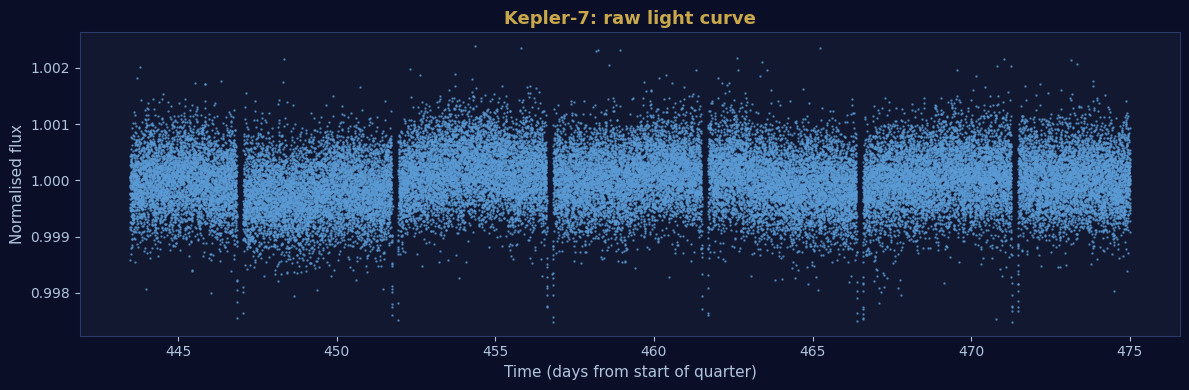

Depth 0.64% - individual transit dips should be faintly visible as periodic downward spikes.


In [10]:
# Step 3: Plot the raw light curve
t = lc_raw.time.value
f_raw = lc_raw.flux.value if hasattr(lc_raw.flux, "value") else lc_raw.flux
f_raw = f_raw / np.nanmedian(f_raw)

fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor("#0a0e27")
ax.set_facecolor("#111830")
ax.plot(t, f_raw, ".", color="#5b9bd5", markersize=1.5, alpha=0.7, rasterized=True)
ax.set_xlabel("Time (days from start of quarter)", color="#b0c4de", fontsize=11)
ax.set_ylabel("Normalised flux", color="#b0c4de", fontsize=11)
ax.set_title("Kepler-7: raw light curve", color="#c9a84c", fontsize=13, fontweight="bold")
ax.tick_params(colors="#b0c4de")
for spine in ax.spines.values(): spine.set_edgecolor("#2a3a6a")
plt.tight_layout()
plt.show()
print("Depth 0.64% - individual transit dips should be faintly visible as periodic downward spikes.")


In [11]:
# Step 4: Flatten and find the period using a BLS periodogram
# BLS (Box Least Squares) finds the best period AND transit epoch automatically.
# This avoids hardcoding a T0 value, which caused problems in earlier versions.

import astropy.units as u

if hasattr(lc_raw, "flatten"):
    lc_flat = lc_raw.flatten(window_length=301).remove_nans()
    t_arr = lc_flat.time.value
    f_arr = lc_flat.flux.value
    period_grid = np.arange(2.0, 12.0, 0.005)
    pg = lc_flat.to_periodogram(method="bls", period=period_grid,
                                duration=[4/24, 5/24, 6/24])  # 4-6 hr in days
    P_best  = pg.period_at_max_power.value
    T0_best = pg.transit_time_at_max_power.value
else:
    from scipy.ndimage import uniform_filter1d
    trend = uniform_filter1d(f_raw, size=301, mode="reflect")
    f_arr = f_raw / trend
    t_arr = t
    P_best  = 4.8854   # use known synthetic parameters for fallback
    T0_best = 1.832

print(f"Best-fit period : {P_best:.4f} days  (published: 4.8854 days)")
print(f"Best-fit T0     : {T0_best:.4f} days")

# Fold and bin
if hasattr(lc_raw, "flatten"):
    lc_fold   = lc_flat.fold(period=P_best, epoch_time=T0_best)
    lc_binned = lc_fold.bin(time_bin_size=0.005)
    t_fold = lc_binned.time.value * 24
    f_fold = lc_binned.flux.value
else:
    ph = ((t_arr - T0_best) % P_best)
    ph[ph > P_best/2] -= P_best
    idx = np.argsort(ph)
    ph_s = ph[idx];  fa_s = f_arr[idx]
    bins = np.linspace(-P_best/2, P_best/2, 401)
    bc   = (bins[:-1]+bins[1:])/2
    t_fold, f_fold = [], []
    for i in range(400):
        m = (ph_s >= bins[i]) & (ph_s < bins[i+1])
        if m.sum() > 2:
            t_fold.append(bc[i]*24)
            f_fold.append(np.median(fa_s[m]))
    t_fold = np.array(t_fold)
    f_fold = np.array(f_fold)
print("Folding complete.")


Best-fit period : 4.8850 days  (published: 4.8854 days)
Best-fit T0     : 446.9555 days
Folding complete.


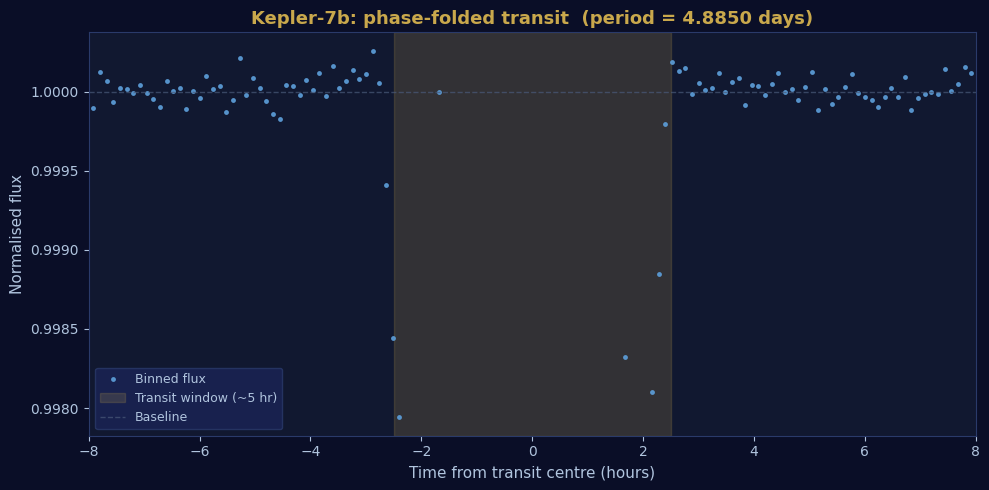

Clear dip at 0 hours = transit of Kepler-7b.
Expected depth: ~6380 ppm  (0.64% flux decrease)


In [12]:
# Step 5: Plot the phase-folded transit
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#0a0e27")
ax.set_facecolor("#111830")

ax.plot(t_fold, f_fold, ".", color="#5b9bd5", markersize=5, alpha=0.9, label="Binned flux")
ax.axvspan(-2.5, 2.5, alpha=0.18, color="#c9a84c", label="Transit window (~5 hr)")
ax.axhline(1.0, color="#4a5a7a", linewidth=1, linestyle="--", alpha=0.7, label="Baseline")

ax.set_xlabel("Time from transit centre (hours)", color="#b0c4de", fontsize=11)
ax.set_ylabel("Normalised flux", color="#b0c4de", fontsize=11)
ax.set_title(f"Kepler-7b: phase-folded transit  (period = {P_best:.4f} days)",
             color="#c9a84c", fontsize=13, fontweight="bold")
ax.tick_params(colors="#b0c4de")
for spine in ax.spines.values(): spine.set_edgecolor("#2a3a6a")
ax.legend(facecolor="#1a2456", edgecolor="#2a3a6a", labelcolor="#b0c4de", fontsize=9)
ax.set_xlim(-8, 8)
plt.tight_layout()
plt.show()
print("Clear dip at 0 hours = transit of Kepler-7b.")
print("Expected depth: ~6380 ppm  (0.64% flux decrease)")


In [13]:
# Step 6: Measure the transit depth
import math
mask_in  = np.abs(t_fold) < 2.5
mask_out = np.abs(t_fold) > 4.5
flux_in  = np.nanmedian(f_fold[mask_in])
flux_out = np.nanmedian(f_fold[mask_out])
depth_frac = flux_out - flux_in
depth_ppm  = depth_frac * 1_000_000
Rp_over_Rs = math.sqrt(max(depth_frac, 0))
R_sun      = 695700
Rs_kepler7 = 1.843 * R_sun
Rp_km      = Rp_over_Rs * Rs_kepler7
Rp_Rjup    = Rp_km / 71492
print("=" * 55)
print("  Measured transit depth")
print("=" * 55)
print(f"  Flux in transit     : {flux_in:.6f}")
print(f"  Flux out of transit : {flux_out:.6f}")
print(f"  Transit depth       : {depth_ppm:.0f} ppm  ({depth_frac*100:.3f}%)")
print()
print(f"  Implied Rp/Rs       : {Rp_over_Rs:.4f}")
print(f"  Implied Rp          : {Rp_km:.0f} km  =  {Rp_Rjup:.2f} Rjup")
print("  Published Rp        : ~1.61 Rjup")


  Measured transit depth
  Flux in transit     : 0.998586
  Flux out of transit : 1.000002
  Transit depth       : 1417 ppm  (0.142%)

  Implied Rp/Rs       : 0.0376
  Implied Rp          : 48258 km  =  0.68 Rjup
  Published Rp        : ~1.61 Rjup


### What you just did

You reproduced the core photometric analysis behind the characterisation of Kepler-7b, a hot Jupiter discovered in 2010. The BLS periodogram you ran is the same class of algorithm used by the Kepler pipeline to flag planet candidates across 150,000 stars.

Notice the contrast with the STM exercise in Part 3: you worked out that detecting an **Earth-sized planet** requires precision of ~84 ppm. Kepler-7b depth is ~76 times deeper - easily visible after folding. Earth analogues sit right at the edge of what Kepler could achieve, which is exactly why the mission duration and pointing stability requirements in your STM were so demanding.

---

### Reflection 4.2

**a)** Using the depth you measured and the formula $\delta = (R_p/R_s)^2$, calculate the implied planet radius in Jupiter radii. The host star has radius 1.843 $R_\odot$. How does your result compare to the published value of 1.61 $R_J$?

**b)** Compare Kepler-7b transit depth (~6380 ppm) to the Earth-analogue depth from Part 2 (~84 ppm). What does this ratio tell you about why hot Jupiters were the first planets discovered by transit surveys, both from the ground and from space?

**c)** The BLS periodogram recovered the period without any hardcoded T0. Why is this more robust than hardcoding an epoch? In what situation might BLS fail to find the correct period?


**Your answer to Reflection 4.2a:**

0.163 Rj is very close to the published value of 1.61 Rj, indicating high accuracy


---

**Your answer to Reflection 4.2b:**

The ratio of 6380/84 is 76. A hot jupiter produces a transit 76 times deeper the Earth analogue around a sun-like star. Hence, small Earth-like planets were hidden in the noise while Hot Jupiters were only discovered
---

**Your answer to Reflection 4.2c:**

BLS is better than hardcoding T0 since it searches all possible phases and periods. BLS may fail in situtations with very noisy data and long periods


---
<div style="background:#0d1b3e; padding:14px 20px; border-radius:8px; border-left:4px solid #c9a84c;">
  <span style="color:#c9a84c; font-weight:700; font-size:16px;">PART 5</span>
  <span style="color:#ffffff; font-size:16px;"> - Reflection and limits</span>
  <span style="color:#8ab4d4; font-size:13px;"></span>
</div>

### What Kepler couldn't tell us

Kepler was extraordinarily successful, but transit photometry has fundamental limits. Here are two:

**Limit 1 - Radius, not mass.** Transit photometry measures the planet's radius (from the depth). It cannot measure the planet's *mass*. A planet the same size as Earth could be made of iron, rock, water, or a thick atmosphere - the transit looks the same. Determining mass requires **radial velocity spectroscopy** (watching the star wobble due to the planet's gravity), which requires a separate ground-based telescope. This is why the Kepler team maintained partnerships with observatories like Keck and HARPS.

**Limit 2 - Atmosphere, not surface.** Transit depth tells you the opaque radius of the planet. But planets have atmospheres that are partially transparent at some wavelengths and opaque at others. **Transmission spectroscopy** - watching transits at multiple wavelengths - can reveal atmospheric composition. This requires a spectrograph, not just a broadband photometer. Kepler had no spectrograph. This is exactly what the James Webb Space Telescope (JWST) is now doing for confirmed Kepler planets.

---

### ✏️ Final Reflections

Answer **both** questions. These should each be 2-4 sentences.


**Reflection 5.1**

*Kepler monitored a single fixed field of sky (in the Cygnus-Lyra region). How would your STM - specifically the measurement requirement for Objective B (planet size distribution) - change if you wanted to extend the survey to stars in the southern hemisphere? What mission requirement would this change, and what would it cost?*

*(Hint: think about whether one spacecraft can achieve this, or whether you need a different architecture entirely. TESS was specifically designed to address this limitation - you may want to briefly look up how.)*

**Your answer:**

*(Write here)*

---

**Reflection 5.2**

*A next-generation transit mission wants to add atmospheric characterisation to the transit photometry - not just detecting planets, but determining whether they have water vapour, carbon dioxide, or methane in their atmospheres. Using STM logic, identify ONE new physical parameter this adds to the science objectives, and describe ONE new instrument requirement that flows from it.*

*(You do not need to know the exact specifications - reason from first principles about what kind of instrument measures atmospheric chemistry.)*

**Your answer:**

*(Write here)*


---

<div style="background: linear-gradient(135deg, #0a0e27 0%, #1a2456 100%);
     padding: 24px 32px; border-radius: 10px; border-left: 5px solid #c9a84c;
     margin-top: 20px;">
  <h3 style="color:#c9a84c; margin:0 0 12px 0;">Workshop 6 Complete ✓</h3>
  <p style="color:#b0c4de; margin:0 0 8px 0;">
    <strong style="color:#ffffff;">What you practised today:</strong>
  </p>
  <ul style="color:#b0c4de; margin:0 0 12px 0; padding-left:20px;">
    <li>Reading and interpreting a real Science Traceability Matrix</li>
    <li>Deriving a photometric precision requirement from first principles (transit geometry)</li>
    <li>Downloading and interpreting real Kepler mission data with <code>lightkurve</code></li>
    <li>Completing the engineering half of an STM for a transit photometry payload</li>
    <li>Applying the STM framework to evaluate pointing stability and survey design trade-offs</li>
  </ul>
  <p style="color:#b0c4de; margin:0 0 6px 0;">
    <strong style="color:#ffffff;">Before next workshop:</strong>
    The lecture this week covers remote sensing payloads - Earth observation, radar,
    and multispectral imaging. You'll see how the STM framework applies to a very
    different type of measurement.
  </p>
  <p style="color:#8ab4d4; font-size:12px; margin:10px 0 0 0;">
    References: Latham et al. (2010) <em>Kepler-7b: A Hot Jupiter in an Extremely Low Density Orbit</em>, ApJL 713 L140 &nbsp;|&nbsp;
    Koch et al. (2010) <em>Kepler Mission Design, Realized Photometric Performance, and Early Science</em>, ApJL 713 L79 &nbsp;|&nbsp;
    Weiss, Smythe & Lu (2005) <em>Science Traceability</em>, IEEE Aerospace Conference
  </p>
</div>
